# Assignment 5.1: Prompt Engineering for a Multi-Step Financial Problem

**Problem statement:** Calculate the final amount in an investment account over 5 years given varying annual returns, a fixed annual fee, and a tax rate on the gains.

**Target prompt given to the (hypothetical) language model:**
> Calculate the final amount in an investment account over 5 years. Initial investment: \$10,000. Annual returns: 5%, 7%, -2%, 10%, 6%. Annual fee: \$100. Tax rate on gains: 15%.

**Assumptions (applied consistently in every technique):**
1. Each year the return is applied to the start-of-year balance.
2. Tax (15%) is charged only on a positive investment gain for that year. A loss is not taxed and does not create a tax credit.
3. The fixed \$100 fee is deducted at the end of each year, after tax. The fee is not tax-deductible.
4. The end-of-year balance becomes the next year's starting balance.

**Techniques implemented:**
1. Chain-of-Thought (CoT) prompting
2. Self-Consistency Chain-of-Thought (SC-CoT) prompting
3. Few-Shot prompting with a simulated model (`SimpleModel`)
4. Additional analysis (sensitivity and self-consistency robustness)
5. Summary and conclusions

In [1]:
# ============================================================
# Setup: imports, logging, target prompt
# ============================================================
import re
import sys
import math
import random
import logging
from collections import Counter
from dataclasses import dataclass
from typing import List

import pandas as pd
import matplotlib.pyplot as plt

# Logging goes to stdout so every reasoning step appears in the notebook output
logging.basicConfig(level=logging.INFO, format="%(message)s", stream=sys.stdout, force=True)
log = logging.getLogger("prompt_engineering")

pd.set_option("display.float_format", lambda v: f"{v:,.2f}")
plt.rcParams["figure.figsize"] = (10, 5)

PROMPT = (
    "Calculate the final amount in an investment account over 5 years. "
    "Initial investment: $10,000. "
    "Annual returns: 5%, 7%, -2%, 10%, 6%. "
    "Annual fee: $100. "
    "Tax rate on gains: 15%."
)
TOLERANCE = 0.01   # two answers "match" if they differ by at most 1 cent

print("Target prompt:\n", PROMPT)

Target prompt:
 Calculate the final amount in an investment account over 5 years. Initial investment: $10,000. Annual returns: 5%, 7%, -2%, 10%, 6%. Annual fee: $100. Tax rate on gains: 15%.


## Shared Utilities

- `parse_prompt()` acts as the model's comprehension step. It reads the natural-language prompt and extracts the numbers, so every technique is driven by the prompt text rather than hard-coded values.
- `run_strategy()` is a configurable calculation engine. It is used to simulate correct and flawed reasoning in the SC-CoT and Few-Shot sections.

In [2]:
@dataclass
class InvestmentProblem:
    initial: float
    returns: List[float]
    fee: float
    tax_rate: float
    years: int


def _to_number(text: str) -> float:
    return float(text.replace(",", ""))


def parse_prompt(prompt: str) -> InvestmentProblem:
    """Extract the problem parameters from a natural-language prompt."""
    initial_m = re.search(r"Initial investment:\s*\$([\d,]+(?:\.\d+)?)", prompt)
    returns_m = re.search(r"Annual returns:(.*?)Annual fee", prompt, re.S)
    fee_m     = re.search(r"Annual fee:\s*\$([\d,]+(?:\.\d+)?)", prompt)
    tax_m     = re.search(r"Tax rate[^:]*:\s*(\d+(?:\.\d+)?)\s*%", prompt)
    years_m   = re.search(r"over\s+(\d+)\s+years?", prompt)

    if not all([initial_m, returns_m, fee_m, tax_m]):
        raise ValueError("Prompt must state the initial investment, annual returns, annual fee and tax rate.")

    returns = [float(x) / 100 for x in re.findall(r"-?\d+(?:\.\d+)?", returns_m.group(1))]
    years = int(years_m.group(1)) if years_m else len(returns)
    if years != len(returns):
        raise ValueError(f"Prompt says {years} years but lists {len(returns)} annual returns.")

    return InvestmentProblem(
        initial=_to_number(initial_m.group(1)),
        returns=returns,
        fee=_to_number(fee_m.group(1)),
        tax_rate=float(tax_m.group(1)) / 100,
        years=years,
    )


def run_strategy(p: InvestmentProblem, tax_losses=False, fee_before_tax=False,
                 apply_tax=True, apply_fee=True):
    """
    Configurable calculation engine.
    Default flags = the correct method (tax positive gains only, then deduct fee).
    The other flags reproduce common reasoning mistakes.
    Returns (final_balance, list_of_yearly_rows).
    """
    balance, rows = p.initial, []
    for year, r in enumerate(p.returns, start=1):
        start = balance
        gain = start * r
        fee = p.fee if apply_fee else 0.0
        taxable = gain - fee if fee_before_tax else gain
        if not apply_tax:
            tax = 0.0
        elif tax_losses:
            tax = taxable * p.tax_rate              # negative tax = credit on losses
        else:
            tax = max(taxable, 0.0) * p.tax_rate
        balance = start + gain - tax - fee
        rows.append({"Year": year, "Start": start, "Gain": gain, "Tax": tax, "Fee": fee, "End": balance})
    return balance, rows


# Quick check that the parser reads the prompt correctly
problem = parse_prompt(PROMPT)
problem

InvestmentProblem(initial=10000.0, returns=[0.05, 0.07, -0.02, 0.1, 0.06], fee=100.0, tax_rate=0.15, years=5)

## 1. Chain-of-Thought (CoT) Prompting

CoT prompting asks the model to "think step by step" instead of jumping to an answer. `chain_of_thought(prompt)` imitates the response an LLM would produce:

1. Extract the facts from the prompt.
2. State a plan (the order of operations).
3. Reason through each year, logging the gain, the tax decision, the fee and the end balance.
4. Verify the result with an independent accounting identity:
   final = initial + Σ gains − Σ taxes − Σ fees
5. State the final answer.

In [3]:
def chain_of_thought(prompt: str):
    """Solve the investment problem step by step, logging every reasoning step."""
    log.info("=" * 80)
    log.info("CHAIN-OF-THOUGHT PROMPTING")
    log.info("=" * 80)
    log.info("Engineered CoT prompt sent to the model:")
    log.info(f'   "{prompt} Let\'s think step by step, showing the calculation for each year."\n')

    # ---- Step 1: extract facts ---------------------------------------------
    log.info("STEP 1 - Extract the facts from the prompt")
    p = parse_prompt(prompt)
    log.info(f"   Initial investment : ${p.initial:,.2f}")
    log.info(f"   Annual returns     : {', '.join(f'{r:+.1%}' for r in p.returns)}")
    log.info(f"   Annual fixed fee   : ${p.fee:,.2f}")
    log.info(f"   Tax rate on gains  : {p.tax_rate:.0%}")
    log.info(f"   Horizon            : {p.years} years\n")

    # ---- Step 2: plan ------------------------------------------------------
    log.info("STEP 2 - Plan the reasoning (repeated for every year)")
    log.info("   a) gain  = start balance x annual return")
    log.info("   b) tax   = gain x tax rate, ONLY if gain > 0 (losses are not taxed)")
    log.info("   c) fee   = fixed annual fee, deducted at year end after tax")
    log.info("   d) end   = start + gain - tax - fee  ->  becomes next year's start\n")

    # ---- Step 3: reason year by year --------------------------------------
    log.info("STEP 3 - Reason through each year")
    balance, records = p.initial, []
    for year, r in enumerate(p.returns, start=1):
        start = balance
        gain = start * r
        after_return = start + gain
        if gain > 0:
            tax = gain * p.tax_rate
            tax_note = f"gain is positive -> tax = ${gain:,.2f} x {p.tax_rate:.0%} = ${tax:,.2f}"
        else:
            tax = 0.0
            tax_note = f"gain is {'negative' if gain < 0 else 'zero'} (${gain:,.2f}) -> no tax owed"
        after_tax = after_return - tax
        end = after_tax - p.fee

        log.info(f"\n   Year {year}  (return {r:+.1%})")
        log.info(f"     3a. Start balance        = ${start:,.2f}")
        log.info(f"     3b. Gain/loss            = ${start:,.2f} x {r:+.2%} = ${gain:,.2f}")
        log.info(f"     3c. Balance after return = ${start:,.2f} + ${gain:,.2f} = ${after_return:,.2f}")
        log.info(f"     3d. Tax check            : {tax_note}")
        log.info(f"     3e. Balance after tax    = ${after_return:,.2f} - ${tax:,.2f} = ${after_tax:,.2f}")
        log.info(f"     3f. Deduct annual fee    = ${after_tax:,.2f} - ${p.fee:,.2f} = ${end:,.2f}")

        records.append({
            "Year": year, "Return %": r * 100, "Start Balance": start,
            "Gain/Loss": gain, "Tax": tax, "Fee": p.fee, "End Balance": end,
        })
        balance = end

    df = pd.DataFrame(records)

    # ---- Step 4: verify ----------------------------------------------------
    total_gain, total_tax, total_fee = df["Gain/Loss"].sum(), df["Tax"].sum(), df["Fee"].sum()
    identity = p.initial + total_gain - total_tax - total_fee
    log.info("\nSTEP 4 - Self-check with an accounting identity")
    log.info(f"   initial + total gains - total taxes - total fees")
    log.info(f"   = ${p.initial:,.2f} + ${total_gain:,.2f} - ${total_tax:,.2f} - ${total_fee:,.2f}")
    log.info(f"   = ${identity:,.2f}")
    log.info(f"   Identity matches year-by-year result: {abs(identity - balance) < 1e-9}")

    # ---- Step 5: answer ----------------------------------------------------
    final = round(balance, 2)
    log.info(f"\nSTEP 5 - FINAL ANSWER: After {p.years} years the account holds ${final:,.2f}")
    return final, df


cot_final, cot_table = chain_of_thought(PROMPT)
display(cot_table)

CHAIN-OF-THOUGHT PROMPTING
Engineered CoT prompt sent to the model:
   "Calculate the final amount in an investment account over 5 years. Initial investment: $10,000. Annual returns: 5%, 7%, -2%, 10%, 6%. Annual fee: $100. Tax rate on gains: 15%. Let's think step by step, showing the calculation for each year."

STEP 1 - Extract the facts from the prompt
   Initial investment : $10,000.00
   Annual returns     : +5.0%, +7.0%, -2.0%, +10.0%, +6.0%
   Annual fixed fee   : $100.00
   Tax rate on gains  : 15%
   Horizon            : 5 years

STEP 2 - Plan the reasoning (repeated for every year)
   a) gain  = start balance x annual return
   b) tax   = gain x tax rate, ONLY if gain > 0 (losses are not taxed)
   c) fee   = fixed annual fee, deducted at year end after tax
   d) end   = start + gain - tax - fee  ->  becomes next year's start

STEP 3 - Reason through each year

   Year 1  (return +5.0%)
     3a. Start balance        = $10,000.00
     3b. Gain/loss            = $10,000.00 x +5.0

,Year,Return %,Start Balance,Gain/Loss,Tax,Fee,End Balance
0,1,5.00,"10,000.00",500.00,75.00,100.00,"10,325.00"
1,2,7.00,"10,325.00",722.75,108.41,100.00,"10,839.34"
2,3,-2.00,"10,839.34",-216.79,0.00,100.00,"10,522.55"
3,4,10.00,"10,522.55","1,052.26",157.84,100.00,"11,316.97"
4,5,6.00,"11,316.97",679.02,101.85,100.00,"11,794.13"


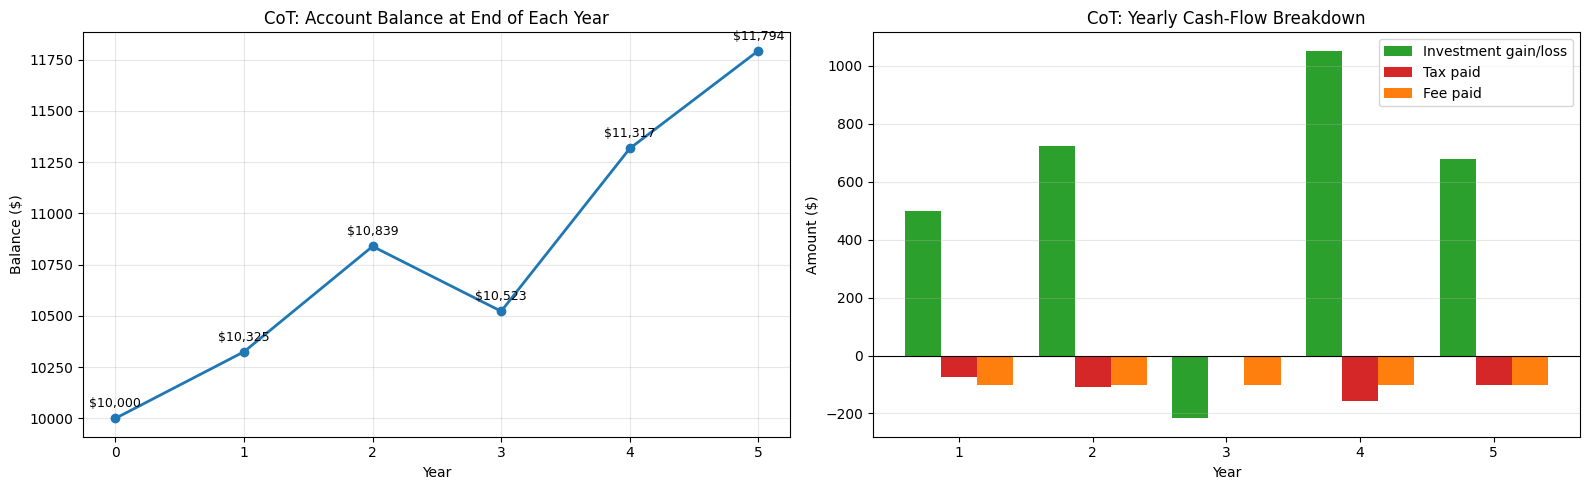

Total investment gains : $2,737.24
Total taxes paid       : $443.10
Total fees paid        : $500.00
Final amount           : $11,794.13
Net growth             : 17.94%
Annualised (CAGR)      : 3.36%
Value with no tax/fees : $12,838.01  -> taxes and fees cost $1,043.88


In [4]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# (a) Account balance over time
years = [0] + cot_table["Year"].tolist()
balances = [cot_table["Start Balance"].iloc[0]] + cot_table["End Balance"].tolist()
ax = axes[0]
ax.plot(years, balances, marker="o", linewidth=2, color="tab:blue")
for x, y in zip(years, balances):
    ax.annotate(f"${y:,.0f}", (x, y), textcoords="offset points", xytext=(0, 8), ha="center", fontsize=9)
ax.set_title("CoT: Account Balance at End of Each Year")
ax.set_xlabel("Year")
ax.set_ylabel("Balance ($)")
ax.grid(alpha=0.3)

# (b) Yearly breakdown of gain, tax and fee
ax = axes[1]
x, w = cot_table["Year"], 0.27
ax.bar(x - w, cot_table["Gain/Loss"], w, label="Investment gain/loss", color="tab:green")
ax.bar(x, -cot_table["Tax"], w, label="Tax paid", color="tab:red")
ax.bar(x + w, -cot_table["Fee"], w, label="Fee paid", color="tab:orange")
ax.axhline(0, color="black", linewidth=0.8)
ax.set_title("CoT: Yearly Cash-Flow Breakdown")
ax.set_xlabel("Year")
ax.set_ylabel("Amount ($)")
ax.legend()
ax.grid(alpha=0.3, axis="y")

plt.tight_layout()
plt.show()

# Totals and the cost of taxes and fees
gross_final = problem.initial * math.prod(1 + r for r in problem.returns)
print(f"Total investment gains : ${cot_table['Gain/Loss'].sum():,.2f}")
print(f"Total taxes paid       : ${cot_table['Tax'].sum():,.2f}")
print(f"Total fees paid        : ${cot_table['Fee'].sum():,.2f}")
print(f"Final amount           : ${cot_final:,.2f}")
print(f"Net growth             : {cot_final / problem.initial - 1:.2%}")
print(f"Annualised (CAGR)      : {(cot_final / problem.initial) ** (1 / problem.years) - 1:.2%}")
print(f"Value with no tax/fees : ${gross_final:,.2f}  -> taxes and fees cost ${gross_final - cot_final:,.2f}")

## 2. Self-Consistency Chain-of-Thought (SC-CoT) Prompting

Self-consistency samples several independent reasoning paths and accepts the answer they agree on. `self_consistency_chain_of_thought(prompt)` does this in two parts.

**Part 1: Independent solution methods.** Three different methods are run, and their results are compared pairwise with a \$0.01 tolerance:

- **Path A, Sequential simulation:** year-by-year bookkeeping.
- **Path B, After-tax growth factor:** each year collapses into one multiplier, m = 1 + r(1 − t) for gains and m = 1 + r for losses, so balance = balance × m − fee.
- **Path C, Closed-form formula:** FV = P·∏mᵢ − Σₖ fee·∏ⱼ₍ⱼ>ₖ₎ mⱼ. Each fee is "compounded forward" to year 5.

**Part 2: Simulated LLM sampling with majority vote.** A real LLM sampled at temperature > 0 sometimes makes mistakes. Examples include forgetting the tax, taxing losses, or deducting the fee before tax. Fifteen sampled paths are simulated with a 30% error rate, and the majority answer is selected.

In [5]:
# ---------------- Independent reasoning paths ----------------
def path_sequential(p, verbose=True):
    """Path A: year-by-year bookkeeping."""
    balance = p.initial
    for year, r in enumerate(p.returns, start=1):
        start = balance
        gain = start * r
        tax = gain * p.tax_rate if gain > 0 else 0.0
        balance = start + gain - tax - p.fee
        if verbose:
            log.info(f"    Year {year}: ${start:,.2f} + gain ${gain:,.2f} - tax ${tax:,.2f} "
                     f"- fee ${p.fee:,.2f} = ${balance:,.2f}")
    return balance


def path_growth_factor(p, verbose=True):
    """Path B: one after-tax growth multiplier per year."""
    balance = p.initial
    for year, r in enumerate(p.returns, start=1):
        m = 1 + r * (1 - p.tax_rate) if r > 0 else 1 + r
        prev = balance
        balance = balance * m - p.fee
        if verbose:
            rule = f"1 + {r:.2%} x (1 - {p.tax_rate:.0%})" if r > 0 else f"1 + ({r:.2%})  [loss, untaxed]"
            log.info(f"    Year {year}: m = {rule} = {m:.6f};  ${prev:,.2f} x {m:.6f} - ${p.fee:,.2f} = ${balance:,.2f}")
    return balance


def path_closed_form(p, verbose=True):
    """Path C: FV = P * prod(m) - sum_k fee * prod(m_j for j > k)."""
    m = [1 + r * (1 - p.tax_rate) if r > 0 else 1 + r for r in p.returns]
    grown_principal = p.initial * math.prod(m)
    fee_fvs = [p.fee * math.prod(m[k + 1:]) for k in range(len(m))]
    result = grown_principal - sum(fee_fvs)
    if verbose:
        log.info(f"    Multipliers m       = {[round(x, 6) for x in m]}")
        log.info(f"    Product of m        = {math.prod(m):.6f}")
        log.info(f"    Principal grown     = ${p.initial:,.2f} x {math.prod(m):.6f} = ${grown_principal:,.2f}")
        for k, fv in enumerate(fee_fvs, start=1):
            log.info(f"    Fee year {k} valued at end of year {p.years} = ${fv:,.2f}")
        log.info(f"    FV = ${grown_principal:,.2f} - ${sum(fee_fvs):,.2f} = ${result:,.2f}")
    return result


# Flawed reasoning patterns a sampled LLM might produce
MISTAKES = {
    "Flawed: forgot the tax":          dict(apply_tax=False),
    "Flawed: tax credit on losses":    dict(tax_losses=True),
    "Flawed: fee deducted before tax": dict(fee_before_tax=True),
    "Flawed: forgot the fee":          dict(apply_fee=False),
}


def self_consistency_chain_of_thought(prompt: str, n_samples=15, error_rate=0.30, seed=42, tol=TOLERANCE):
    log.info("=" * 80)
    log.info("SELF-CONSISTENCY CHAIN-OF-THOUGHT PROMPTING")
    log.info("=" * 80)
    p = parse_prompt(prompt)

    # ---------- PART 1: independent methods ----------
    log.info("PART 1 - Solve the problem with independent reasoning paths")
    paths = {
        "Path A - Sequential simulation":  path_sequential,
        "Path B - After-tax growth factor": path_growth_factor,
        "Path C - Closed-form formula":     path_closed_form,
    }
    results = {}
    for name, fn in paths.items():
        log.info(f"\n  --- {name} ---")
        results[name] = fn(p, verbose=True)
        log.info(f"    RESULT: ${results[name]:,.2f}")

    log.info("\n  Pairwise consistency check (tolerance ${:.2f})".format(tol))
    names, all_match = list(results), True
    for i in range(len(names)):
        for j in range(i + 1, len(names)):
            diff = abs(results[names[i]] - results[names[j]])
            ok = diff <= tol
            all_match = all_match and ok
            log.info(f"    {names[i].split(' -')[0]} vs {names[j].split(' -')[0]}: "
                     f"${results[names[i]]:,.6f} vs ${results[names[j]]:,.6f}  |diff| = {diff:.2e}  "
                     f"-> {'MATCH' if ok else 'MISMATCH'}")
    log.info(f"  All independent paths consistent: {all_match}")

    # ---------- PART 2: sampled paths + majority vote ----------
    log.info(f"\nPART 2 - Sample {n_samples} reasoning paths (simulated error rate {error_rate:.0%}) and vote")
    rng = random.Random(seed)
    samples = []
    for i in range(1, n_samples + 1):
        if rng.random() < error_rate:
            label = rng.choice(list(MISTAKES))
            value, _ = run_strategy(p, **MISTAKES[label])
            kind = "flawed"
        else:
            label = rng.choice(names)
            value = paths[label](p, verbose=False)
            kind = "sound"
        answer = round(value, 2)
        samples.append({"Sample": i, "Reasoning path": label, "Type": kind, "Answer ($)": answer})
        log.info(f"    Sample {i:2d}: {label:<34} -> ${answer:,.2f}")

    votes = Counter(s["Answer ($)"] for s in samples)
    log.info("\n  Vote tally:")
    for ans, cnt in votes.most_common():
        log.info(f"    ${ans:,.2f}: {cnt} vote(s)")
    majority, count = votes.most_common(1)[0]
    log.info(f"  Majority answer: ${majority:,.2f} ({count}/{n_samples} = {count / n_samples:.0%} agreement)")

    deterministic = round(results[names[0]], 2)
    agrees = abs(majority - deterministic) <= tol
    log.info(f"  Majority vote agrees with the independent methods: {agrees}")

    final = deterministic if all_match else majority
    log.info(f"\nFINAL SELF-CONSISTENT ANSWER: ${final:,.2f}")
    return {"paths": results, "all_match": all_match, "samples": pd.DataFrame(samples),
            "votes": votes, "majority": majority, "final": final}


sc = self_consistency_chain_of_thought(PROMPT)
display(pd.DataFrame({"Reasoning path": list(sc["paths"]), "Result ($)": list(sc["paths"].values())}))
display(sc["samples"])

SELF-CONSISTENCY CHAIN-OF-THOUGHT PROMPTING
PART 1 - Solve the problem with independent reasoning paths

  --- Path A - Sequential simulation ---
    Year 1: $10,000.00 + gain $500.00 - tax $75.00 - fee $100.00 = $10,325.00
    Year 2: $10,325.00 + gain $722.75 - tax $108.41 - fee $100.00 = $10,839.34
    Year 3: $10,839.34 + gain $-216.79 - tax $0.00 - fee $100.00 = $10,522.55
    Year 4: $10,522.55 + gain $1,052.26 - tax $157.84 - fee $100.00 = $11,316.97
    Year 5: $11,316.97 + gain $679.02 - tax $101.85 - fee $100.00 = $11,794.13
    RESULT: $11,794.13

  --- Path B - After-tax growth factor ---
    Year 1: m = 1 + 5.00% x (1 - 15%) = 1.042500;  $10,000.00 x 1.042500 - $100.00 = $10,325.00
    Year 2: m = 1 + 7.00% x (1 - 15%) = 1.059500;  $10,325.00 x 1.059500 - $100.00 = $10,839.34
    Year 3: m = 1 + (-2.00%)  [loss, untaxed] = 0.980000;  $10,839.34 x 0.980000 - $100.00 = $10,522.55
    Year 4: m = 1 + 10.00% x (1 - 15%) = 1.085000;  $10,522.55 x 1.085000 - $100.00 = $11,316.97

,Reasoning path,Result ($)
0,Path A - Sequential simulation,"11,794.13"
1,Path B - After-tax growth factor,"11,794.13"
2,Path C - Closed-form formula,"11,794.13"


,Sample,Reasoning path,Type,Answer ($)
0,1,Path A - Sequential simulation,sound,"11,794.13"
1,2,Path A - Sequential simulation,sound,"11,794.13"
2,3,Flawed: forgot the tax,flawed,"12,278.88"
3,4,Path C - Closed-form formula,sound,"11,794.13"
4,5,Flawed: forgot the fee,flawed,"12,343.42"
5,6,Flawed: forgot the tax,flawed,"12,278.88"
6,7,Flawed: forgot the tax,flawed,"12,278.88"
7,8,Path C - Closed-form formula,sound,"11,794.13"
8,9,Path C - Closed-form formula,sound,"11,794.13"
9,10,Path B - After-tax growth factor,sound,"11,794.13"


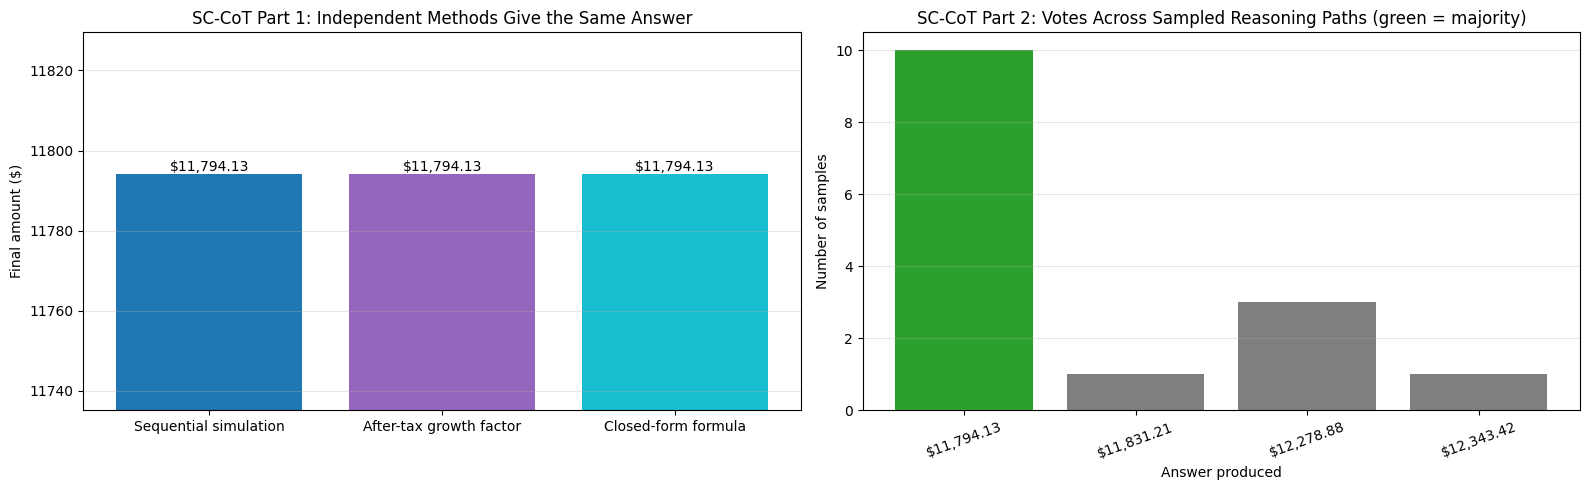

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# (a) Independent methods agree
ax = axes[0]
labels = [n.split(" - ")[1] for n in sc["paths"]]
vals = list(sc["paths"].values())
bars = ax.bar(labels, vals, color=["tab:blue", "tab:purple", "tab:cyan"])
for b, v in zip(bars, vals):
    ax.text(b.get_x() + b.get_width() / 2, v, f"${v:,.2f}", ha="center", va="bottom", fontsize=10)
ax.set_ylim(min(vals) * 0.995, max(vals) * 1.003)
ax.set_title("SC-CoT Part 1: Independent Methods Give the Same Answer")
ax.set_ylabel("Final amount ($)")
ax.grid(alpha=0.3, axis="y")

# (b) Majority vote across sampled paths
ax = axes[1]
vote_items = sorted(sc["votes"].items())
colors = ["tab:green" if a == sc["majority"] else "tab:gray" for a, _ in vote_items]
ax.bar([f"${a:,.2f}" for a, _ in vote_items], [c for _, c in vote_items], color=colors)
ax.set_title("SC-CoT Part 2: Votes Across Sampled Reasoning Paths (green = majority)")
ax.set_xlabel("Answer produced")
ax.set_ylabel("Number of samples")
ax.tick_params(axis="x", rotation=20)
ax.grid(alpha=0.3, axis="y")

plt.tight_layout()
plt.show()

## 3. Few-Shot Prompting

Few-shot prompting shows the model a handful of solved examples so it can infer the procedure. In this problem, the procedure means the order of operations and how losses are taxed.

- **`SimpleModel`** simulates training. It holds five candidate procedures, a "hypothesis space" an LLM could follow. During `train()`, it scores each candidate against the worked examples and keeps the one that reproduces them. `predict()` then applies the learned procedure to the target prompt and explains each year.
- **`few_shot_prompting(model, examples, prompt)`** trains the model, builds the actual few-shot prompt text that would be sent to an LLM, and returns the prediction.
- **Ablation:** the model is retrained with 1, 2 and 3 examples to show how example selection affects accuracy.

Example answers were worked out by hand under the stated assumptions.

In [7]:
# Worked examples (hand-calculated): include a loss year so the tax rule is demonstrated
EXAMPLES = [
    {
        "prompt": ("Calculate the final amount in an investment account over 2 years. "
                   "Initial investment: $1,000. Annual returns: 10%, 10%. Annual fee: $10. Tax rate on gains: 20%."),
        "answer": ("Year 1: 1000 + 100 gain - 20 tax - 10 fee = 1070.00; "
                   "Year 2: 1070 + 107 gain - 21.40 tax - 10 fee = 1145.60. The final amount is $1,145.60."),
    },
    {
        "prompt": ("Calculate the final amount in an investment account over 2 years. "
                   "Initial investment: $5,000. Annual returns: -10%, 20%. Annual fee: $50. Tax rate on gains: 10%."),
        "answer": ("Year 1: 5000 - 500 loss (no tax on a loss) - 50 fee = 4450.00; "
                   "Year 2: 4450 + 890 gain - 89 tax - 50 fee = 5201.00. The final amount is $5,201.00."),
    },
    {
        "prompt": ("Calculate the final amount in an investment account over 3 years. "
                   "Initial investment: $2,000. Annual returns: 5%, 5%, 5%. Annual fee: $20. Tax rate on gains: 25%."),
        "answer": ("Year 1: 2000 + 100 - 25 - 20 = 2055.00; Year 2: 2055 + 102.75 - 25.69 - 20 = 2112.06; "
                   "Year 3: 2112.06 + 105.60 - 26.40 - 20 = 2171.26. The final amount is $2,171.26."),
    },
]

# Hypothesis space: procedures the model might follow (order matters only for tie-breaking)
CANDIDATE_STRATEGIES = {
    "Ignore tax, deduct fee":             dict(apply_tax=False),
    "Tax gains, ignore fee":              dict(apply_fee=False),
    "Deduct fee before computing tax":    dict(fee_before_tax=True),
    "Tax gains, credit losses, then fee": dict(tax_losses=True),
    "Tax positive gains only, then fee":  dict(),
}


def extract_answer(text: str) -> float:
    m = re.search(r"final amount is \$([\d,]+(?:\.\d+)?)", text)
    if not m:
        raise ValueError(f"No final amount found in: {text}")
    return _to_number(m.group(1))


class SimpleModel:
    """A toy 'language model' that learns a calculation procedure from worked examples."""

    def __init__(self, candidate_strategies, tol=TOLERANCE):
        self.candidates = candidate_strategies
        self.tol = tol
        self.examples = []
        self.learned_strategy = None
        self.training_report = None
        self.ambiguous = False
        self.last_trace = None

    def train(self, examples):
        self.examples = list(examples)
        log.info(f"  Training on {len(self.examples)} example(s); scoring {len(self.candidates)} candidate procedures")
        rows = []
        for name, flags in self.candidates.items():
            errors = []
            for ex in self.examples:
                pred, _ = run_strategy(parse_prompt(ex["prompt"]), **flags)
                errors.append(abs(pred - extract_answer(ex["answer"])))
            matched = sum(e <= self.tol for e in errors)
            mean_err = sum(errors) / len(errors)
            rows.append({"Strategy": name, "Examples matched": matched,
                         "Total examples": len(errors), "Mean abs error ($)": mean_err})
            log.info(f"    {name:<36} matched {matched}/{len(errors)}   mean error ${mean_err:,.2f}")

        self.training_report = pd.DataFrame(rows)
        perfect = self.training_report.loc[self.training_report["Mean abs error ($)"] <= self.tol, "Strategy"].tolist()
        self.ambiguous = len(perfect) > 1
        self.learned_strategy = self.training_report.loc[self.training_report["Mean abs error ($)"].idxmin(), "Strategy"]
        if self.ambiguous:
            log.warning(f"  WARNING: {len(perfect)} procedures fit the examples perfectly {perfect}; "
                        f"the examples do not disambiguate them.")
        log.info(f"  Learned procedure: '{self.learned_strategy}'")
        return self

    def build_prompt(self, prompt):
        parts = ["You are a careful financial assistant. Solve the question the same way as the examples.\n"]
        for i, ex in enumerate(self.examples, start=1):
            parts.append(f"Example {i}:\nQ: {ex['prompt']}\nA: {ex['answer']}\n")
        parts.append(f"Now solve:\nQ: {prompt}\nA:")
        return "\n".join(parts)

    def predict(self, prompt, explain=True):
        if self.learned_strategy is None:
            raise RuntimeError("Model must be trained before predicting.")
        p = parse_prompt(prompt)
        final, rows = run_strategy(p, **self.candidates[self.learned_strategy])
        self.last_trace = pd.DataFrame(rows)
        if explain:
            log.info(f"  Applying learned procedure '{self.learned_strategy}':")
            for r in rows:
                log.info(f"    Year {r['Year']}: ${r['Start']:,.2f} + gain ${r['Gain']:,.2f} "
                         f"- tax ${r['Tax']:,.2f} - fee ${r['Fee']:,.2f} = ${r['End']:,.2f}")
        return f"The final amount is ${final:,.2f}"


def few_shot_prompting(model, examples, prompt):
    log.info("=" * 80)
    log.info("FEW-SHOT PROMPTING")
    log.info("=" * 80)
    log.info("STEP 1 - Train the model with the worked examples")
    model.train(examples)
    log.info("\nSTEP 2 - Few-shot prompt that would be sent to the language model:")
    log.info("-" * 80)
    log.info(model.build_prompt(prompt))
    log.info("-" * 80)
    log.info("\nSTEP 3 - Predict the response for the target prompt")
    response = model.predict(prompt)
    log.info(f"\nMODEL RESPONSE: {response}")
    return response


fs_model = SimpleModel(CANDIDATE_STRATEGIES)
fs_response = few_shot_prompting(fs_model, EXAMPLES, PROMPT)
fs_value = extract_answer(fs_response)
display(fs_model.training_report)
display(fs_model.last_trace)

FEW-SHOT PROMPTING
STEP 1 - Train the model with the worked examples
  Training on 3 example(s); scoring 5 candidate procedures
    Ignore tax, deduct fee               matched 0/3   mean error $71.11
    Tax gains, ignore fee                matched 0/3   mean error $64.03
    Deduct fee before computing tax      matched 0/3   mean error $8.24
    Tax gains, credit losses, then fee   matched 2/3   mean error $19.67
    Tax positive gains only, then fee    matched 3/3   mean error $0.00
  Learned procedure: 'Tax positive gains only, then fee'

STEP 2 - Few-shot prompt that would be sent to the language model:
--------------------------------------------------------------------------------
You are a careful financial assistant. Solve the question the same way as the examples.

Example 1:
Q: Calculate the final amount in an investment account over 2 years. Initial investment: $1,000. Annual returns: 10%, 10%. Annual fee: $10. Tax rate on gains: 20%.
A: Year 1: 1000 + 100 gain - 20 tax - 1

,Strategy,Examples matched,Total examples,Mean abs error ($)
0,"Ignore tax, deduct fee",0,3,71.11
1,"Tax gains, ignore fee",0,3,64.03
2,Deduct fee before computing tax,0,3,8.24
3,"Tax gains, credit losses, then fee",2,3,19.67
4,"Tax positive gains only, then fee",3,3,0.00


,Year,Start,Gain,Tax,Fee,End
0,1,"10,000.00",500.00,75.00,100.00,"10,325.00"
1,2,"10,325.00",722.75,108.41,100.00,"10,839.34"
2,3,"10,839.34",-216.79,0.00,100.00,"10,522.55"
3,4,"10,522.55","1,052.26",157.84,100.00,"11,316.97"
4,5,"11,316.97",679.02,101.85,100.00,"11,794.13"



Training with the first 1 example(s):

Training with the first 2 example(s):

Training with the first 3 example(s):


,# examples,Learned procedure,Ambiguous?,Prediction ($),Correct?
0,1,"Tax gains, credit losses, then fee",True,"11,831.21",False
1,2,"Tax positive gains only, then fee",False,"11,794.13",True
2,3,"Tax positive gains only, then fee",False,"11,794.13",True


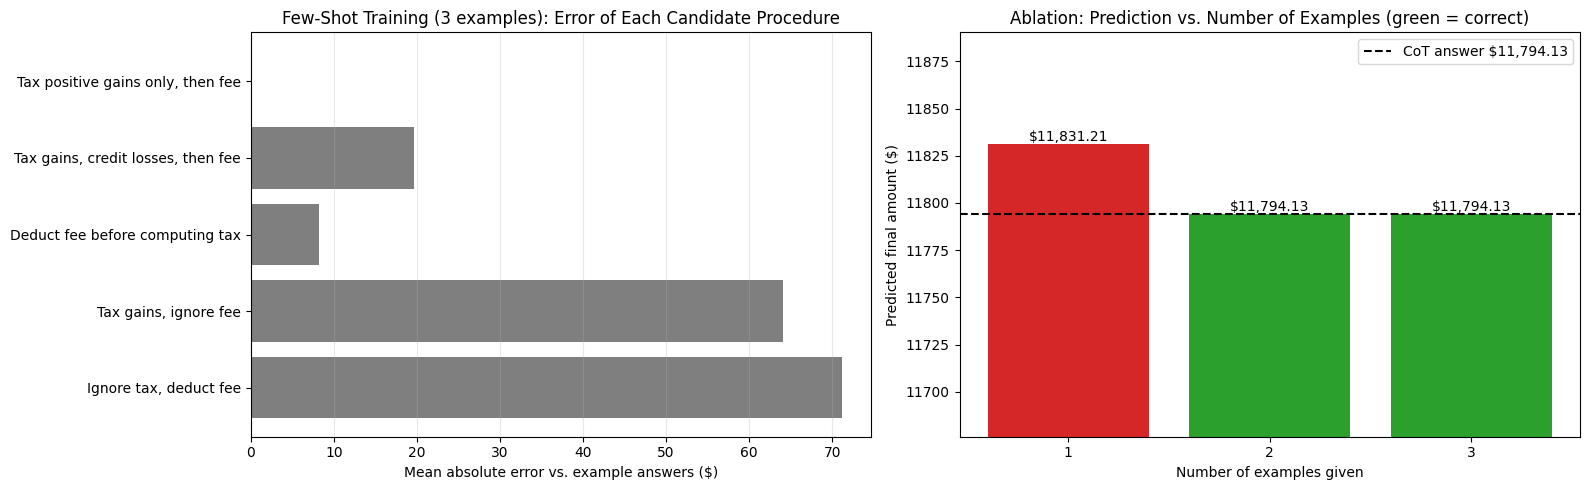

In [8]:
ablation = []
log.setLevel(logging.WARNING)            # keep this experiment's output short
try:
    for k in range(1, len(EXAMPLES) + 1):
        print(f"\nTraining with the first {k} example(s):")
        m = SimpleModel(CANDIDATE_STRATEGIES).train(EXAMPLES[:k])
        pred = extract_answer(m.predict(PROMPT, explain=False))
        ablation.append({"# examples": k, "Learned procedure": m.learned_strategy,
                         "Ambiguous?": m.ambiguous, "Prediction ($)": pred,
                         "Correct?": abs(pred - cot_final) <= TOLERANCE})
finally:
    log.setLevel(logging.INFO)

ablation_df = pd.DataFrame(ablation)
display(ablation_df)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

ax = axes[0]
rep = fs_model.training_report
colors = ["tab:green" if s == fs_model.learned_strategy else "tab:gray" for s in rep["Strategy"]]
ax.barh(rep["Strategy"], rep["Mean abs error ($)"], color=colors)
ax.set_title("Few-Shot Training (3 examples): Error of Each Candidate Procedure")
ax.set_xlabel("Mean absolute error vs. example answers ($)")
ax.grid(alpha=0.3, axis="x")

ax = axes[1]
colors = ["tab:green" if c else "tab:red" for c in ablation_df["Correct?"]]
bars = ax.bar(ablation_df["# examples"], ablation_df["Prediction ($)"], color=colors)
ax.set_xticks(ablation_df["# examples"])
ax.axhline(cot_final, color="black", linestyle="--", label=f"CoT answer ${cot_final:,.2f}")
for b, v in zip(bars, ablation_df["Prediction ($)"]):
    ax.text(b.get_x() + b.get_width() / 2, v, f"${v:,.2f}", ha="center", va="bottom")
ax.set_ylim(cot_final * 0.99, ablation_df["Prediction ($)"].max() * 1.005)
ax.set_title("Ablation: Prediction vs. Number of Examples (green = correct)")
ax.set_xlabel("Number of examples given")
ax.set_ylabel("Predicted final amount ($)")
ax.legend()

plt.tight_layout()
plt.show()

In [9]:
comparison = pd.DataFrame({
    "Technique": ["Chain-of-Thought", "Self-Consistency CoT", "Few-Shot (3 examples)"],
    "Final amount ($)": [cot_final, sc["final"], fs_value],
})
comparison["Matches CoT?"] = (comparison["Final amount ($)"] - cot_final).abs() <= TOLERANCE
display(comparison)
print(f"All three techniques agree on ${cot_final:,.2f}: {comparison['Matches CoT?'].all()}")

,Technique,Final amount ($),Matches CoT?
0,Chain-of-Thought,"11,794.13",True
1,Self-Consistency CoT,"11,794.13",True
2,Few-Shot (3 examples),"11,794.13",True


All three techniques agree on $11,794.13: True


## 4. Additional Analysis

### 4.1 Sensitivity Analysis: Tax Rate and Annual Fee
This analysis recalculates the final amount under different tax rates (0–30%) and annual fees (\$0–\$200), keeping the same returns. It shows how much each cost lever affects the outcome. The base case (15% tax, \$100 fee) should equal the CoT answer.

Annual fee ($),0,50,100,150,200
Tax rate,,,,,
0%,"12,838.01","12,558.44","12,278.88","11,999.31","11,719.74"
10%,"12,506.70","12,230.42","11,954.14","11,677.87","11,401.59"
15%,"12,343.42","12,068.78","11,794.13","11,519.49","11,244.84"
20%,"12,181.71","11,908.70","11,635.68","11,362.66","11,089.64"
25%,"12,021.57","11,750.17","11,478.77","11,207.37","10,935.97"
30%,"11,862.97","11,593.18","11,323.39","11,053.61","10,783.82"


Base case (15% tax, $100 fee) = $11,794.13  -> matches CoT: True
Raising the fee $100 -> $150 reduces the final amount by $274.64
Raising the tax 15% -> 20% reduces the final amount by $158.46


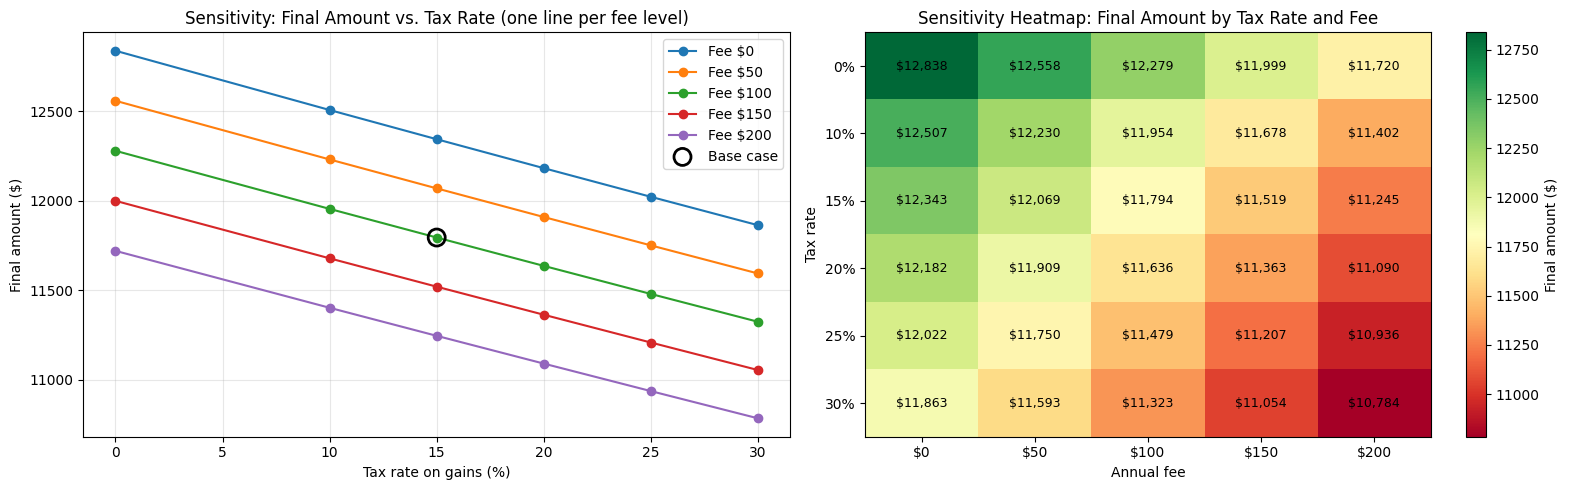

In [10]:
# ============================================================
# 4.1 Sensitivity analysis: tax rate x annual fee
# ============================================================
tax_rates = [0.0, 0.10, 0.15, 0.20, 0.25, 0.30]
fee_levels = [0, 50, 100, 150, 200]

rows = []
for t in tax_rates:
    for f in fee_levels:
        p = InvestmentProblem(problem.initial, problem.returns, float(f), t, problem.years)
        final, _ = run_strategy(p)
        rows.append({"Tax rate": f"{t:.0%}", "Annual fee ($)": f, "Final amount ($)": final})

sens = pd.DataFrame(rows)
sens_table = sens.pivot(index="Tax rate", columns="Annual fee ($)", values="Final amount ($)")
display(sens_table)

base = sens_table.loc["15%", 100]
print(f"Base case (15% tax, $100 fee) = ${base:,.2f}  -> matches CoT: {abs(base - cot_final) <= TOLERANCE}")
print(f"Raising the fee $100 -> $150 reduces the final amount by ${base - sens_table.loc['15%', 150]:,.2f}")
print(f"Raising the tax 15% -> 20% reduces the final amount by ${base - sens_table.loc['20%', 100]:,.2f}")

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# (a) Final amount vs tax rate for each fee level
ax = axes[0]
for f in fee_levels:
    vals = [sens_table.loc[f"{t:.0%}", f] for t in tax_rates]
    ax.plot([t * 100 for t in tax_rates], vals, marker="o", label=f"Fee ${f}")
ax.scatter([15], [cot_final], s=150, facecolors="none", edgecolors="black", linewidths=2, zorder=5,
           label="Base case")
ax.set_title("Sensitivity: Final Amount vs. Tax Rate (one line per fee level)")
ax.set_xlabel("Tax rate on gains (%)")
ax.set_ylabel("Final amount ($)")
ax.legend()
ax.grid(alpha=0.3)

# (b) Heatmap of the full grid
ax = axes[1]
im = ax.imshow(sens_table.values, cmap="RdYlGn", aspect="auto")
ax.set_xticks(range(len(sens_table.columns)))
ax.set_xticklabels([f"${c}" for c in sens_table.columns])
ax.set_yticks(range(len(sens_table.index)))
ax.set_yticklabels(sens_table.index)
for i in range(sens_table.shape[0]):
    for j in range(sens_table.shape[1]):
        ax.text(j, i, f"${sens_table.values[i, j]:,.0f}", ha="center", va="center", fontsize=9)
ax.set_title("Sensitivity Heatmap: Final Amount by Tax Rate and Fee")
ax.set_xlabel("Annual fee")
ax.set_ylabel("Tax rate")
fig.colorbar(im, ax=ax, label="Final amount ($)")

plt.tight_layout()
plt.show()

### 4.2 How Robust Is Self-Consistency? (Error-Rate Experiment)
The SC-CoT function is rerun 50 times (different random seeds) at each simulated error rate from 0% to 90%. Two accuracies are compared:
- **Single-path accuracy:** how often one sampled reasoning path is correct (ordinary CoT with sampling).
- **Majority-vote accuracy:** how often the self-consistency majority answer is correct.

,Error rate,Single-path accuracy,Majority-vote accuracy
0,0%,100%,100%
1,10%,92%,100%
2,30%,70%,100%
3,50%,48%,92%
4,70%,20%,48%
5,90%,10%,2%


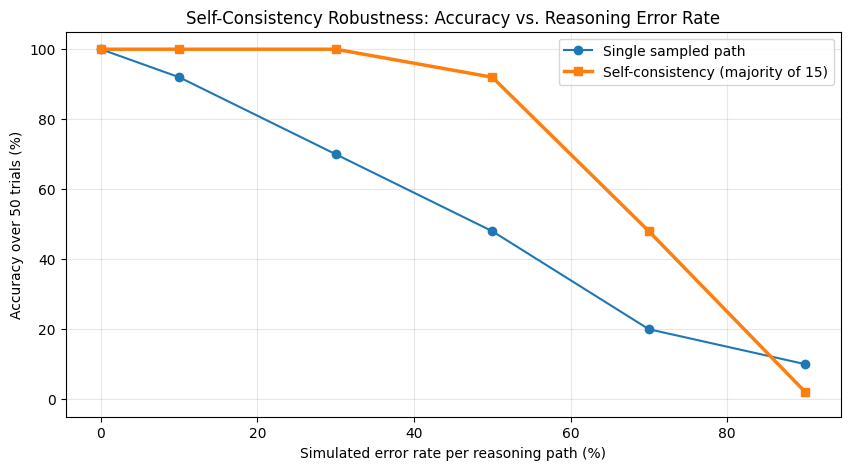

In [11]:
# ============================================================
# 4.2 Self-consistency robustness vs. error rate
# ============================================================
error_rates = [0.0, 0.1, 0.3, 0.5, 0.7, 0.9]
n_trials = 50
correct_answer = round(cot_final, 2)

exp_rows = []
log.setLevel(logging.WARNING)     # silence the detailed logs for this repeated experiment
try:
    for er in error_rates:
        majority_hits, single_hits = 0, 0
        for seed in range(n_trials):
            res = self_consistency_chain_of_thought(PROMPT, n_samples=15, error_rate=er, seed=seed)
            majority_hits += abs(res["majority"] - correct_answer) <= TOLERANCE
            single_hits += abs(res["samples"]["Answer ($)"].iloc[0] - correct_answer) <= TOLERANCE
        exp_rows.append({"Error rate": f"{er:.0%}",
                         "Single-path accuracy": single_hits / n_trials,
                         "Majority-vote accuracy": majority_hits / n_trials})
finally:
    log.setLevel(logging.INFO)

robust_df = pd.DataFrame(exp_rows)
display(robust_df.style.format({"Single-path accuracy": "{:.0%}", "Majority-vote accuracy": "{:.0%}"}))

fig, ax = plt.subplots(figsize=(10, 5))
x = [er * 100 for er in error_rates]
ax.plot(x, robust_df["Single-path accuracy"] * 100, marker="o", label="Single sampled path")
ax.plot(x, robust_df["Majority-vote accuracy"] * 100, marker="s", linewidth=2.5, label="Self-consistency (majority of 15)")
ax.set_title("Self-Consistency Robustness: Accuracy vs. Reasoning Error Rate")
ax.set_xlabel("Simulated error rate per reasoning path (%)")
ax.set_ylabel("Accuracy over 50 trials (%)")
ax.set_ylim(-5, 105)
ax.legend()
ax.grid(alpha=0.3)
plt.show()

## 5. Summary and Conclusions

### Result
All three techniques agree. A \$10,000 investment with returns of +5%, +7%, −2%, +10% and +6%, a \$100 annual fee and a 15% tax on gains grows to **\$11,794.13** after 5 years.

| Item | Amount |
|---|---|
| Total investment gains | \$2,737.24 |
| Total taxes paid | \$443.10 |
| Total fees paid | \$500.00 |
| Net growth / CAGR | 17.94% / about 3.36% per year |

Without taxes and fees the account would reach about \$12,838. Taxes and fees together therefore cost about \$1,044. That is more than the \$943 paid directly, because the money paid out also loses its future compounding. In year 3 the −2% loss produced no tax, and the fee was still charged.

### Insights by technique

**Chain-of-Thought.** Breaking the problem into explicit steps (extract → plan → yearly calculation → verify → answer) makes every intermediate value auditable. The decisions that are easy to get wrong become visible in the log: whether a loss is taxed, and whether the fee comes before or after tax. The built-in accounting-identity check gives the chain a self-verification step.

**Self-Consistency CoT.** Three mathematically different methods (sequential, growth-factor, closed-form) produced identical results to within about 1e-12. This gives strong evidence the answer is correct. In the simulated sampling, about 30% of paths contained realistic mistakes, yet the majority vote still recovered \$11,794.13. The flawed answers scattered across different wrong values while the sound paths converged on one. This is the core idea of self-consistency: errors tend to disagree, and correct reasoning tends to agree.

**Few-Shot.** The model inferred the correct procedure from three worked examples. The ablation shows that example *selection* matters more than example *count*. With only Example 1, which has no loss year, two procedures fit perfectly, and the model chose the one that gives a tax credit on losses. It then predicted the wrong answer for the target. Adding Example 2, which contains a loss, removed the ambiguity. Good few-shot examples must cover the edge cases present in the target problem.

**Sensitivity analysis.** The heatmap shows that both the fee and the tax rate steadily reduce the final amount, and the base case reproduces the CoT result exactly (\$11,794.13). Raising the annual fee from \$100 to \$150 lowers the final amount by \$274.64, while raising the tax rate from 15% to 20% lowers it by only \$158.46. The fixed fee is the stronger lever here because it is charged every year regardless of performance and loses its compounding, while tax only applies in years with positive gains. The final amount ranges from \$10,783.82 (30% tax, \$200 fee) to \$12,838.01 (no tax, no fee).

**Self-consistency robustness.** Majority voting is much more accurate than a single sampled path. With a 30% error rate per path, a single path is correct only 70% of the time, but the majority vote is correct in 100% of trials. At a 50% error rate it is still correct 92% of the time, compared with 48% for a single path. This works because flawed paths split across several *different* wrong answers while sound paths all agree on one. The benefit shrinks as errors grow: at 70% the vote is correct 48% of the time (single path: 20%). At 90%, voting becomes *worse* than a single path (2% vs. 10%), because one wrong answer becomes the most common and the vote locks onto it. Self-consistency therefore helps only when the model's reasoning is correct more often than any single mistake is repeated. It amplifies the dominant answer, whether that answer is right or wrong.

### Overall takeaways
1. CoT improves transparency. SC-CoT improves reliability. Few-shot transfers a specific convention, such as "losses are not taxed," that the model could not otherwise know.
2. The techniques work best combined: few-shot examples written as step-by-step answers are effectively few-shot CoT, and sampling them several times adds self-consistency.
3. For financial calculations, stating assumptions explicitly in the prompt (tax timing, fee order, loss treatment) matters as much as the prompting technique.

### Limitations
`SimpleModel` and the sampled reasoning paths are simulations of LLM behaviour, not a real LLM. The prompt parser expects a fixed sentence pattern. Paths B and C assume the balance stays positive. A real deployment would use an LLM API with temperature sampling and more flexible parsing.